# Pràctica 1: Identificació d'Idioma
## Fase 0 — Configuració i Exploració del Corpus

In [1]:
# Imports i configuració global
import os
import re
import math
import zipfile
import collections
import nltk


from pathlib import Path

# Definim les constants del projecte
LANGUAGES   = ['deu', 'eng', 'spa', 'fra', 'ita', 'nld']
TRAIN_SIZE  = 30_000
TEST_SIZE   = 10_000
DATA_DIR    = Path("langId")

### Exploració del format dels fitxers


In [2]:
# Inspeccionem les primeres 5 línies raw del fitxer de training anglès
sample_file = os.path.join(DATA_DIR, 'eng_trn.txt')

with open(sample_file, 'r', encoding='utf-8') as f:
    for i, line in enumerate(f):
        print(repr(line))
        if i >= 4:
            break

'1\t• • •\n'
'2\t0.00 0.00% How the mighty have fallen.\n'
"3\t0.00 0.00% Major companies coming out with their latest quarterly numbers include Dave & Buster's, Men's Wearhouse, Palo Alto Networks, Box, Barnes & Noble, Pep Boys-Manny, Moe & Jack, Ollie's Bargain Outlet, DavidsTea, Lululemon Athletica and Kroger.\n"
'4\t01 JANUARY 2015, MAGAZINE Why are there so many Magna Cartas?\n'
'5\t0:44 Now watching Up next 2016 Word Association with Brad Woodhouse The president of the Democratic American Bridge PAC on the GOP presidential field.\n'


### Càrrega completa del corpus

In [3]:
def load_corpus(filepath: str) -> list[str]:
    """
    Llegeix un fitxer del corpus Leipzig.
    Format: <id>\t<text>\n
    Retorna una llista de strings (frases netes).
    """
    sentences = []
    with open(filepath, 'r', encoding='utf-8') as f:
        for line in f:
            parts = line.strip().split('\t')
            text = parts[-1] if len(parts) > 1 else parts[0]
            if text:
                sentences.append(text)
    return sentences


# Carreguem tots els corpus
corpus = {}   # corpus[lang]['train'] / corpus[lang]['test']

for lang in LANGUAGES:
    train_path = os.path.join(DATA_DIR, f'{lang}_trn.txt')
    test_path  = os.path.join(DATA_DIR, f'{lang}_tst.txt')
    corpus[lang] = {
        'train': load_corpus(train_path),
        'test':  load_corpus(test_path)
    }


### Inspecció estadística del corpus

In [4]:
print(f"{'Lang':<6} {'Train':>8} {'Test':>8} {'Avg len train':>15} {'Avg len test':>14}")
print("-" * 55)

for lang in LANGUAGES:
    train_sents = corpus[lang]['train']
    test_sents  = corpus[lang]['test']
    avg_train   = sum(len(s) for s in train_sents) / len(train_sents)
    avg_test    = sum(len(s) for s in test_sents)  / len(test_sents)
    print(f"{lang:<6} {len(train_sents):>8,} {len(test_sents):>8,} "
          f"{avg_train:>14.1f}  {avg_test:>13.1f}")

print()
# Mostrem 2 frases d'exemple per idioma
print("Mostres de frases:")
for lang in LANGUAGES:
    print(f"\n[{lang.upper()}]")
    for s in corpus[lang]['train'][:2]:
        print(f"  {s}")

Lang      Train     Test   Avg len train   Avg len test
-------------------------------------------------------
deu      29,928    9,990          113.0          113.0
eng      29,935    9,987          120.8          120.0
spa      30,000   10,000          131.5          131.9
fra      30,000   10,000          122.7          123.1
ita      30,000   10,000          127.0          127.1
nld      30,000   10,000          106.0          106.1

Mostres de frases:

[DEU]
  04.01.15 Wissenschaft Welche Rolle das Licht im Wissenschaftsjahr 2015 in Jena spielt Weltweit wird 2015 dem Thema Licht große Aufmerksamkeit gewidmet.
  04.04.2014 – 09:54Touristik "Das Magazin für die Freiheit unterwegs": AUTO BILD launcht neue Zeitschrift REISEMOBIL Hamburg (ots) - Die Deutschen sind Reiseweltmeister - auch auf vier Rädern im rollenden Appartement.

[ENG]
  • • •
  0.00 0.00% How the mighty have fallen.

[SPA]
  Denuncia IEM probable fraude con actas electorales El Instituto Electoral de Michoacán denunc

## Fase 1 — Preprocessament del Text


In [5]:
def preprocess(sentences: list[str]) -> str:
    """
    Aplica la pipeline de preprocessament:
      1. Eliminar dígits
      2. Convertir a minúscules
      3. Substituir espais múltiples per un de sol
      4. Concatenar totes les frases amb doble espai
    Retorna un únic string amb tot el corpus preprocessat.
    """
    processed = []
    for sent in sentences:
        s = re.sub(r'\d', '', sent)        # 1. Eliminar dígits
        s = s.lower()                      # 2. Minúscules
        s = re.sub(r' +', ' ', s)          # 3. Espais múltiples → un sol espai
        s = s.strip()
        if s:                              # Descartem línies que queden buides
            processed.append(s)
    return '  '.join(processed)            # 4. Concatenar amb doble espai


### Aplicació i verificació del preprocessament

In [6]:
# Apliquem el preprocessament a tots els corpus
corpus_prep = {}   # corpus_prep[lang]['train'] / ['test']

for lang in LANGUAGES:
    corpus_prep[lang] = {
        'train': preprocess(corpus[lang]['train']),
        'test':  preprocess(corpus[lang]['test'])
    }

# Verificació: mostrem un fragment de cada idioma preprocessat
print("Verificació del preprocessament (primers 200 caràcters de train):\n")
for lang in LANGUAGES:
    print(f"[{lang.upper()}]  {corpus_prep[lang]['train'][:200]}")
    print()

Verificació del preprocessament (primers 200 caràcters de train):

[DEU]  .. wissenschaft welche rolle das licht im wissenschaftsjahr in jena spielt weltweit wird dem thema licht große aufmerksamkeit gewidmet.  .. – :touristik "das magazin für die freiheit unterwegs": auto 

[ENG]  • • •  . .% how the mighty have fallen.  . .% major companies coming out with their latest quarterly numbers include dave & buster's, men's wearhouse, palo alto networks, box, barnes & noble, pep boys

[SPA]  denuncia iem probable fraude con actas electorales el instituto electoral de michoacán denunció ante la fiscalía especializada la presencia de actas de escrutinio y cómputo, al parecer apócrifas, en u

[FRA]  le président de l'om, jean-claude dassier, y confirme à son homologue toulousain, olivier sadran, "l'intérêt de l'olympique de marseille à faire venir le joueur andré-pierre gignac".  il a signé jeudi

[ITA]  "ora questa squadra può fare il salto di qualità".  il kaiser di kerpen, che dovrebbe torn

### Estadístiques post-preprocessament

In [7]:
print(f"{'Lang':<6}  {'Chars train':>12}  {'Chars test':>11}")
print("-" * 35)
for lang in LANGUAGES:
    ct = len(corpus_prep[lang]['train'])
    cv = len(corpus_prep[lang]['test'])
    print(f"{lang:<6}  {ct:>12,}  {cv:>11,}")


Lang     Chars train   Chars test
-----------------------------------
deu        3,405,314    1,136,695
eng        3,635,844    1,204,723
spa        3,965,103    1,325,166
fra        3,698,635    1,236,217
ita        3,830,306    1,277,934
nld        3,173,458    1,059,400


## Fase 2 — Construcció dels Models de Llengua

In [13]:
from nltk.collocations import (BigramCollocationFinder,
                                TrigramCollocationFinder,
                                QuadgramCollocationFinder)

# Paràmetres globals del model
N_GRAM   = 3    # Ordre del model (2, 3 o 4)
LAMBDA   = 0.5  # Suavitzat de Lidstone (λ)
MIN_FREQ = 5    # Filtratge de n-grames poc freqüents

FINDER = {
    2: BigramCollocationFinder,
    3: TrigramCollocationFinder,
    4: QuadgramCollocationFinder,
}[N_GRAM]

print(f"Configuració del model: n={N_GRAM}, λ={LAMBDA}, min_freq={MIN_FREQ}")

Configuració del model: n=3, λ=0.5, min_freq=5


### Extracció de n-grames filtrats (dataset net)

In [14]:
def get_ngram_counts(text: str, finder_cls, min_freq: int) -> collections.Counter:
    """
    Extreu n-grames de caràcters, aplica el filtre de freqüència mínima
    i retorna un Counter — aquest és el dataset net definitiu del model.
    """
    finder = finder_cls.from_words(text)
    finder.apply_freq_filter(min_freq)
    return collections.Counter(dict(finder.ngram_fd))


# Dataset net per a cada idioma: només n-grames amb freq >= MIN_FREQ
raw_counts = {}
for lang in LANGUAGES:
    raw_counts[lang] = get_ngram_counts(corpus_prep[lang]['train'],
                                        FINDER, MIN_FREQ)
    print(f"[{lang.upper()}]  n-grames únics (freq≥{MIN_FREQ}): "
          f"{len(raw_counts[lang]):>8,}")

[DEU]  n-grames únics (freq≥5):   11,321
[ENG]  n-grames únics (freq≥5):    9,392
[SPA]  n-grames únics (freq≥5):    9,294
[FRA]  n-grames únics (freq≥5):   10,600
[ITA]  n-grames únics (freq≥5):    8,339
[NLD]  n-grames únics (freq≥5):   10,148


### Càlcul de N i B sobre el dataset net

In [15]:
# N per idioma = total d'ocurrències al dataset net
N = {}
for lang in LANGUAGES:
    N[lang] = sum(raw_counts[lang].values())
    print(f"[{lang.upper()}]  N (ocurrències al model): {N[lang]:>12,}")

print()

# B global = unió dels n-grames únics de TOTS els models nets
# Espai compartit que permet comparar probabilitats entre idiomes
all_ngrams = set()
for lang in LANGUAGES:
    all_ngrams.update(raw_counts[lang].keys())

B = len(all_ngrams)
print(f"B global (unió de tots els models nets): {B:,} n-grames únics")

[DEU]  N (ocurrències al model):    3,387,083
[ENG]  N (ocurrències al model):    3,621,034
[SPA]  N (ocurrències al model):    3,947,903
[FRA]  N (ocurrències al model):    3,680,862
[ITA]  N (ocurrències al model):    3,813,560
[NLD]  N (ocurrències al model):    3,154,095

B global (unió de tots els models nets): 21,968 n-grames únics


### Construcció dels models finals (log-probabilitats de Lidstone)

In [16]:
def build_model(counts: collections.Counter,
                n_total: int,
                b: int,
                lam: float = LAMBDA) -> dict:
    """
    Construeix el model de llengua amb suavitzat de Lidstone.
    Tots els paràmetres es calculen sobre el dataset net (filtrat).

      counts    : n-grames nets {ngram: freq}
      n_total   : suma total d'ocurrències al dataset net (N)
      b         : unió global de n-grames nets (B)
      lam       : paràmetre lambda de Lidstone

    Retorna:
      'probs'      -> {ngram: log_prob} per als n-grames del model
      'log_unseen' -> log_prob per a qualsevol n-grama fora del model
    """
    denom = n_total + lam * b
    log_unseen = math.log(lam / denom)
    probs = {
        ngram: math.log((count + lam) / denom)
        for ngram, count in counts.items()
    }
    return {'probs': probs, 'log_unseen': log_unseen}


models = {}
for lang in LANGUAGES:
    models[lang] = build_model(raw_counts[lang], N[lang], B)
    print(f"[{lang.upper()}]  log_unseen = {models[lang]['log_unseen']:.4f}"
          f"  |  n-grames al model: {len(models[lang]['probs']):>8,}")

print()
print(f"Top-5 n-grames més probables per idioma (n={N_GRAM}):")
for lang in LANGUAGES:
    top5 = sorted(models[lang]['probs'].items(),
                  key=lambda x: x[1], reverse=True)[:5]
    print(f"  [{lang.upper()}]  {',  '.join(''.join(t) for t, _ in top5)}")

[DEU]  log_unseen = -15.7319  |  n-grames al model:   11,321
[ENG]  log_unseen = -15.7984  |  n-grames al model:    9,392
[SPA]  log_unseen = -15.8846  |  n-grames al model:    9,294
[FRA]  log_unseen = -15.8148  |  n-grames al model:   10,600
[ITA]  log_unseen = -15.8501  |  n-grames al model:    8,339
[NLD]  log_unseen = -15.6608  |  n-grames al model:   10,148

Top-5 n-grames més probables per idioma (n=3):
  [DEU]  en ,  er ,   de,  .  ,  der
  [ENG]   th,  the,  he ,  .  ,  ing
  [SPA]   de,  de ,  os ,   la,  el 
  [FRA]   de,  es ,  de ,   le,  .  
  [ITA]   di,  to ,  .  ,   de,  la 
  [NLD]  en ,  de ,   de,  .  ,  an 


## Fase 3 — Classificador (Inferència)

In [17]:
def score_text(text: str, model: dict, finder_cls) -> float:
    """
    Calcula el log-score d'un text preprocessat donat un model de llengua.
    Retorna la suma de log-probabilitats dels n-grames del text.
    """
    finder = finder_cls.from_words(text)
    ngrams = list(finder.ngram_fd.keys())

    if not ngrams:
        return float('-inf')

    return sum(
        model['probs'].get(ng, model['log_unseen'])
        for ng in ngrams
    )


def classify(sentence: str, models: dict, finder_cls) -> str:
    """
    Classifica una frase preprocessada retornant l'idioma més probable.
    Aplica score_text a cada model i retorna l'argmax.
    """
    scores = {lang: score_text(sentence, models[lang], finder_cls)
              for lang in models}
    return max(scores, key=scores.get)

### Preprocessament del test set frase a frase

In [18]:
def preprocess_single(sentence: str) -> str:
    """
    Aplica la mateixa pipeline de preprocessament que a l'entrenament,
    però per a una sola frase (sense concatenació).
    """
    s = re.sub(r'\d', '', sentence)
    s = s.lower()
    s = re.sub(r' +', ' ', s).strip()
    return s


# Preprocessem cada frase de test individualment
test_sentences = {}

for lang in LANGUAGES:
    test_sentences[lang] = [
        preprocess_single(s)
        for s in corpus[lang]['test']
        if preprocess_single(s)
    ]

print("Frases de test preprocessades:")
for lang in LANGUAGES:
    print(f"  [{lang.upper()}]  {len(test_sentences[lang]):,} frases")

Frases de test preprocessades:
  [DEU]  9,990 frases
  [ENG]  9,987 frases
  [SPA]  10,000 frases
  [FRA]  10,000 frases
  [ITA]  10,000 frases
  [NLD]  10,000 frases


### Validació del classificador amb exemples manuals

In [19]:
print("Validació manual del classificador:\n")
for lang in LANGUAGES:
    print(f"[{lang.upper()}] — mostres:")
    for sent in test_sentences[lang][:3]:
        pred = classify(sent, models, FINDER)
        ok   = "Predicció correcta" if pred == lang else f"Predicció incorrecta (prediu {pred.upper()})"
        print(f"  {ok}  [{pred.upper()}]  {sent[:80]}")
    print()


Validació manual del classificador:

[DEU] — mostres:
  Predicció correcta  [DEU]  : dgap-adhoc: accu holding ag: einladung zur generalversammlung und ernennung ei
  Predicció correcta  [DEU]  .. – : min mediathek familiennachzug von flüchtlingen de-maizière-vorstoß entzwe
  Predicció correcta  [DEU]  day-exploits werden auf dem ohnehin bereits von konkurrierenden geheimdiensten f

[ENG] — mostres:
  Predicció correcta  [ENG]  : autoplay autoplay copy this code to your website or blog moscow — timur the go
  Predicció correcta  [ENG]  : gmt - roadmap signed - the head of the un atomic watchdog says iran has signed
  Predicció correcta  [ENG]  moments from the iraq war photos a boy stands at the scene of a car bombing in f

[SPA] — mostres:
  Predicció correcta  [SPA]  denuncia iem probable fraude con actas electorales el instituto electoral de mic
  Predicció correcta  [SPA]  a pesar de la organización del movimiento, su paisano, abelande, critica la disp
  Predicció correcta  [SPA]  e

## Fase 4 — Avaluació

In [20]:
from sklearn.metrics import (accuracy_score, confusion_matrix,
                              classification_report, ConfusionMatrixDisplay)
import matplotlib.pyplot as plt

# Classifiquem totes les frases de test
y_true = []
y_pred = []

for lang in LANGUAGES:
    for sent in test_sentences[lang]:
        y_true.append(lang)
        y_pred.append(classify(sent, models, FINDER))

print(f"Total frases avaluades: {len(y_true):,}")

Total frases avaluades: 59,977


### Accuracy global

In [21]:
acc = accuracy_score(y_true, y_pred)
print(f"Accuracy global: {acc:.4f}  ({acc*100:.2f}%)")

Accuracy global: 0.9987  (99.87%)


### Matriu de confusió

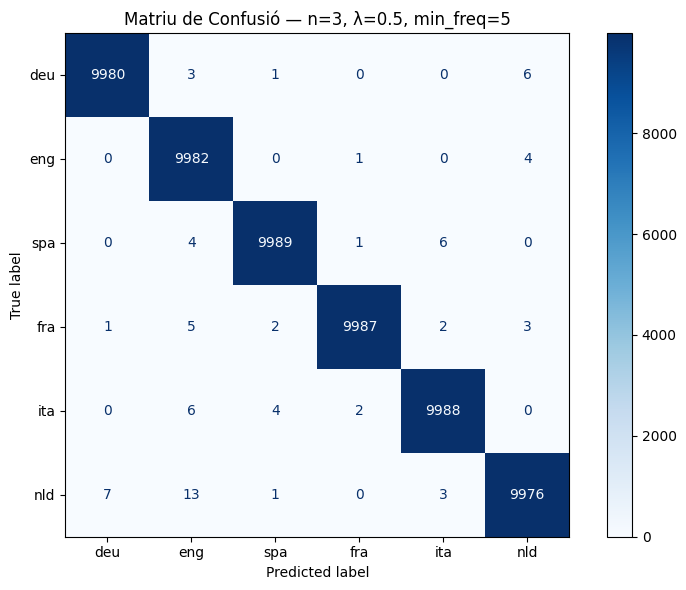

Matriu guardada a confusion_matrix.png


In [22]:
lang_labels = LANGUAGES   # ['deu','eng','spa','fra','ita','nld']

cm = confusion_matrix(y_true, y_pred, labels=lang_labels)

fig, ax = plt.subplots(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=lang_labels)
disp.plot(ax=ax, colorbar=True, cmap='Blues')
ax.set_title(f"Matriu de Confusió — n={N_GRAM}, λ={LAMBDA}, min_freq={MIN_FREQ}")
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=150)
plt.show()
print("Matriu guardada a confusion_matrix.png")


### Report detallat per idioma (Precision, Recall, F1)


In [23]:
print(classification_report(y_true, y_pred,
                             labels=lang_labels,
                             target_names=[l.upper() for l in lang_labels],
                             digits=4))


              precision    recall  f1-score   support

         DEU     0.9992    0.9990    0.9991      9990
         ENG     0.9969    0.9995    0.9982      9987
         SPA     0.9992    0.9989    0.9990     10000
         FRA     0.9996    0.9987    0.9991     10000
         ITA     0.9989    0.9988    0.9988     10000
         NLD     0.9987    0.9976    0.9981     10000

    accuracy                         0.9987     59977
   macro avg     0.9988    0.9987    0.9987     59977
weighted avg     0.9988    0.9987    0.9987     59977



### Anàlisi dels errors: parells de confusió més freqüents


In [25]:
# Identifiquem els errors i els parells de confusió
errors = [(t, p) for t, p in zip(y_true, y_pred) if t != p]
print(f"Total errors: {len(errors)} / {len(y_true)} "
      f"({len(errors)/len(y_true)*100:.2f}%)\n")

error_pairs = collections.Counter(errors).most_common(10)
print("Top-10 parells de confusió (veritat → predicció):")
for (true, pred), count in error_pairs:
    print(f"  {true.upper()} → {pred.upper()} : {count:>5} errors")

Total errors: 75 / 59977 (0.13%)

Top-10 parells de confusió (veritat → predicció):
  NLD → ENG :    13 errors
  NLD → DEU :     7 errors
  DEU → NLD :     6 errors
  SPA → ITA :     6 errors
  ITA → ENG :     6 errors
  FRA → ENG :     5 errors
  ENG → NLD :     4 errors
  SPA → ENG :     4 errors
  ITA → SPA :     4 errors
  DEU → ENG :     3 errors


FALTA PER FER:
- Afegir mètriques d'avaluació 

FASE 5
- Experimentar amb n i lambda
- Experimentra amb frases per longitud -> proposar llindar míonim de confiança

- Log loss
- Accuracy per idiomes

Amb model final
- Analisi frases que fallen i idiomes que es confonen

informe i revisar codi 